**Import libraries**

**Importing libraries**

In [14]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


**Load dataset**

In [15]:
df = pd.read_csv("Mall_Customers.csv")

print(df.head())

   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [16]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

**Feature Scaling**

In [17]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


**Find Optimal Number of Clusters Elbow Method**

In [18]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42
    )

    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

**Plot elbow graph**

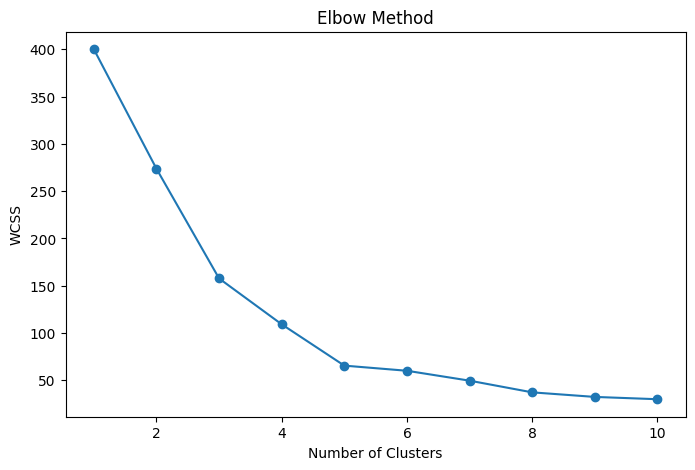

In [19]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

**Train KMeans Model**

In [20]:
kmeans = KMeans(
    n_clusters=5,
    init='k-means++',
    random_state=42
)

y_kmeans = kmeans.fit_predict(X_scaled)

**Add cluster labels**

In [21]:
df['Cluster'] = y_kmeans

print(df.head())

   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        4  
1        2  
2        4  
3        2  
4        4  


**Visualize Clusters**

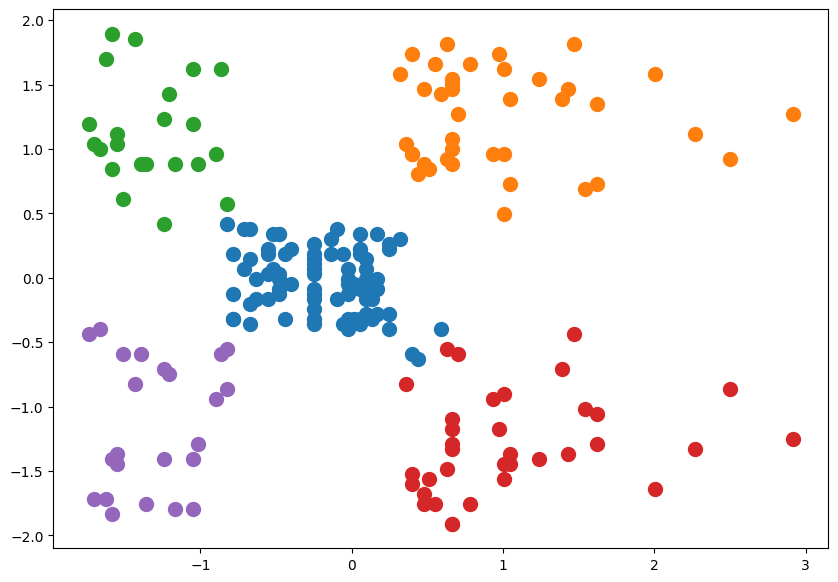

In [22]:
plt.figure(figsize=(10,7))

plt.scatter(
    X_scaled[y_kmeans == 0, 0],
    X_scaled[y_kmeans == 0, 1],
    s=100,
    label='Cluster 1'
)

plt.scatter(
    X_scaled[y_kmeans == 1, 0],
    X_scaled[y_kmeans == 1, 1],
    s=100,
    label='Cluster 2'
)

plt.scatter(
    X_scaled[y_kmeans == 2, 0],
    X_scaled[y_kmeans == 2, 1],
    s=100,
    label='Cluster 3'
)

plt.scatter(
    X_scaled[y_kmeans == 3, 0],
    X_scaled[y_kmeans == 3, 1],
    s=100,
    label='Cluster 4'
)

plt.scatter(
    X_scaled[y_kmeans == 4, 0],
    X_scaled[y_kmeans == 4, 1],
    s=100,
    label='Cluster 5'
)


**Plot centroids**

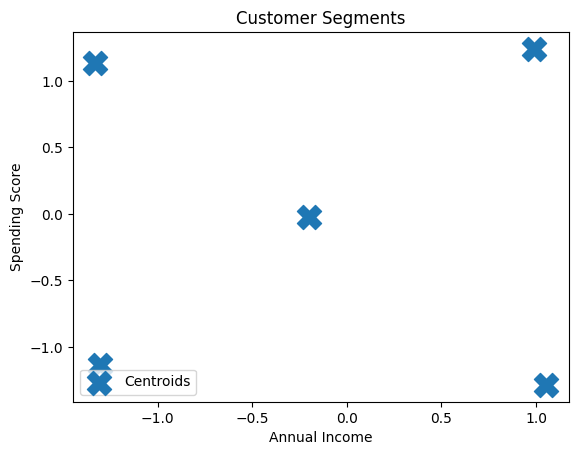

In [23]:
plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=300,
    marker='X',
    label='Centroids'
)

plt.title("Customer Segments")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")

plt.legend()
plt.show()

**Cluster Insights**

In [24]:
cluster_summary = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()

print(cluster_summary)

               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        42.716049           55.296296               49.518519
1        32.692308           86.538462               82.128205
2        25.272727           25.727273               79.363636
3        41.114286           88.200000               17.114286
4        45.217391           26.304348               20.913043
